https://colab.research.google.com/drive/1yVM6PaQttXPTR8QZkg8kYEI9GprdsG3b?usp=sharing

Author: Meliton Rojas

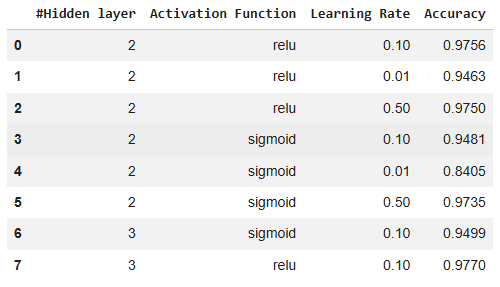

In [ ]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

from keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

In [ ]:
x_train = x_train.reshape(60000, 784).astype('float32')
x_valid = x_valid.reshape(10000, 784).astype('float32')

In [ ]:
x_train /= 255
x_valid /=255

In [ ]:
n_classes = 10
y_train = keras.utils.to_categorical(y_train, n_classes)
y_valid = keras.utils.to_categorical(y_valid, n_classes)

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_90 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.1), metrics=['accuracy'])

In [ ]:
#model.fit(x_train, y_train, batch_size = 128, epochs=20, verbose=1, validation_data=(x_valid, y_valid))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7650 - loss: 0.8021 - val_accuracy: 0.9280 - val_loss: 0.2497
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9318 - loss: 0.2372 - val_accuracy: 0.9420 - val_loss: 0.1969
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9483 - loss: 0.1780 - val_accuracy: 0.9526 - val_loss: 0.1542
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9582 - loss: 0.1443 - val_accuracy: 0.9624 - val_loss: 0.1301
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9636 - loss: 0.1200 - val_accuracy: 0.9670 - val_loss: 0.1092
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9709 - loss: 0.1029 - val_accuracy: 0.9650 - val_loss: 0.1099
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9722 - loss: 0.0963 - val_accuracy: 0.9699 - val_loss: 0.1002
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9766 - loss: 0.0799 - val_accuracy: 0.

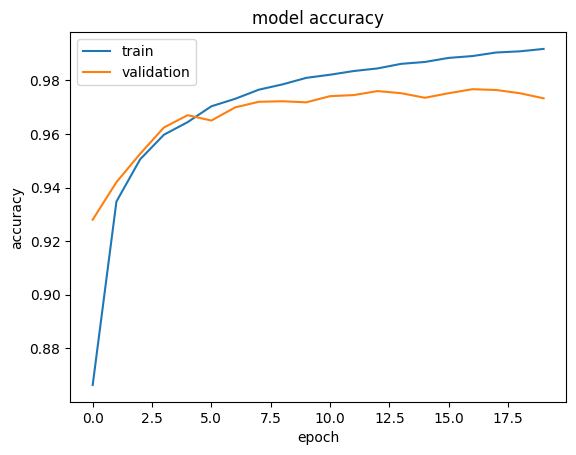

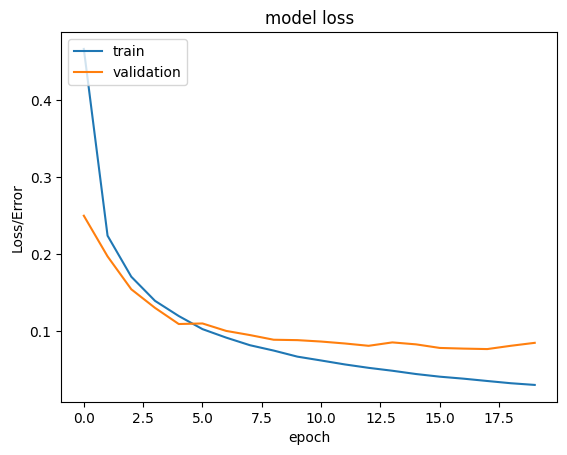

In [ ]:
history = model.fit(x_train, y_train, batch_size = 128, epochs = 20, verbose = 1, validation_data = (x_valid, y_valid))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss/Error')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

#print(history.history.keys())
#pd.DataFrame(history.history).plot(figsize=(8, 5))
#plt.show()

In [ ]:
def build_model(num_hidden_layers=2, activation='relu'):
    model = Sequential()
    model.add(Dense(64, activation=activation, input_shape=(784,)))

    # adding hidden layer
    for _ in range(num_hidden_layers - 1):
        model.add(Dense(64, activation=activation))

    model.add(Dense(10, activation='softmax'))
    return model

configs = [
    {"hidden_layers": 2, "activation": "relu",    "lr": 0.1},
    {"hidden_layers": 2, "activation": "relu",    "lr": 0.01},
    {"hidden_layers": 2, "activation": "relu",    "lr": 0.5},
    {"hidden_layers": 2, "activation": "sigmoid", "lr": 0.1},
    {"hidden_layers": 2, "activation": "sigmoid", "lr": 0.01},
    {"hidden_layers": 2, "activation": "sigmoid", "lr": 0.5},
    {"hidden_layers": 3, "activation": "sigmoid", "lr": 0.1},
    {"hidden_layers": 3, "activation": "relu",    "lr": 0.1},
]

results = []

for cfg in configs:
    print("\nRunning:", cfg)

    model = build_model(cfg["hidden_layers"], cfg["activation"])
    model.compile(
        loss="categorical_crossentropy",
        optimizer=SGD(learning_rate=cfg["lr"]),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train, y_train,
        batch_size=128,
        epochs=20,
        verbose=0,
        validation_data=(x_valid, y_valid),
    )

    accuracy = float(np.max(history.history["val_accuracy"]))

    results.append({
        "#Hidden layer": cfg["hidden_layers"],
        "Activation Function": cfg["activation"],
        "Learning Rate": cfg["lr"],
        "Accuracy": round(accuracy, 4)
    })

df = pd.DataFrame(results)
df


Running: {'hidden_layers': 2, 'activation': 'relu', 'lr': 0.1}

Running: {'hidden_layers': 2, 'activation': 'relu', 'lr': 0.01}

Running: {'hidden_layers': 2, 'activation': 'relu', 'lr': 0.5}

Running: {'hidden_layers': 2, 'activation': 'sigmoid', 'lr': 0.1}

Running: {'hidden_layers': 2, 'activation': 'sigmoid', 'lr': 0.01}

Running: {'hidden_layers': 2, 'activation': 'sigmoid', 'lr': 0.5}

Running: {'hidden_layers': 3, 'activation': 'sigmoid', 'lr': 0.1}

Running: {'hidden_layers': 3, 'activation': 'relu', 'lr': 0.1}


,#Hidden layer,Activation Function,Learning Rate,Accuracy
0,2,relu,0.10,0.9756
1,2,relu,0.01,0.9463
2,2,relu,0.50,0.9750
3,2,sigmoid,0.10,0.9481
4,2,sigmoid,0.01,0.8405
5,2,sigmoid,0.50,0.9735
6,3,sigmoid,0.10,0.9499
7,3,relu,0.10,0.9770
